In [ ]:
import pandas as pd

df = pd.read_csv("policy_sales_data.csv")

df.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Policy_Tenure,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date
0,1,V1,100000,3,300,2024-08-27,2025-08-27,2028-08-26
1,2,V2,100000,3,300,2024-04-14,2025-04-14,2028-04-13
2,3,V3,100000,2,200,2024-05-23,2025-05-23,2027-05-23
3,4,V4,100000,3,300,2024-06-19,2025-06-19,2028-06-18
4,5,V5,100000,2,200,2024-02-15,2025-02-14,2027-02-14


In [ ]:
import pandas as pd

claims_data = pd.read_csv("claims_data.csv")

claims_data.head()

,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,2617,V2617,10000.0,2025-01-02,1
1,9918,V9918,10000.0,2025-08-16,1
2,2305,V2305,10000.0,2025-06-16,1
3,6321,V6321,10000.0,2025-12-21,1
4,3782,V3782,10000.0,2025-12-03,1


In [ ]:
# -------------------------------------
# 1. Total Premium collected in 2024
# -------------------------------------
total_premium = df["Premium"].sum()

print("Total Premium 2024:", total_premium)

Total Premium 2024: 2408800


In [ ]:
# -------------------------------------
# 2. Claim cost by month (2025 & 2026)
# -------------------------------------


claims_data["Claim_Date"] = pd.to_datetime(claims_data["Claim_Date"])

claims_data["Year"] = claims_data["Claim_Date"].dt.year
claims_data["Month"] = claims_data["Claim_Date"].dt.month

monthly_claims = claims_data.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

print(monthly_claims)

    Year  Month  Claim_Amount
0   2024     12       70000.0
1   2025      1     2610000.0
2   2025      2     2070000.0
3   2025      3     2670000.0
4   2025      4     2500000.0
5   2025      5     2700000.0
6   2025      6     2410000.0
7   2025      7     2440000.0
8   2025      8     2430000.0
9   2025      9     2380000.0
10  2025     10     2390000.0
11  2025     11     2550000.0
12  2025     12     2780000.0


In [ ]:
# -------------------------------------
# 3. Claim / Premium ratio by tenure
# -------------------------------------

# Merge policy and claims data
merged = pd.merge(df, claims_data, on=["Customer_ID","Vehicle_ID"], how="left")

# Replace NaN claim values with 0
merged["Claim_Amount"] = merged["Claim_Amount"].fillna(0)

# Group by tenure
ratio_by_tenure = merged.groupby("Policy_Tenure").agg(
    Total_Claims=("Claim_Amount", "sum"),
    Total_Premium=("Premium", "sum")
)

# Calculate claim to premium ratio
ratio_by_tenure["Claim_Premium_Ratio"] = (
    ratio_by_tenure["Total_Claims"] / ratio_by_tenure["Total_Premium"]
)

print(ratio_by_tenure)

               Total_Claims  Total_Premium  Claim_Premium_Ratio
Policy_Tenure                                                  
1                 6030000.0         197900            30.469934
2                 8960000.0         591800            15.140250
3                11870000.0        1217100             9.752691
4                 3140000.0         402000             7.810945


In [ ]:
# -------------------------------------
# 4. Claim ratio by purchase month
# -------------------------------------

# Create purchase month column
df["Purchase_Month"] = pd.to_datetime(df["Policy_Purchase_Date"]).dt.month

# Merge policy and claims data
month_data = pd.merge(df, claims_data, on="Customer_ID", how="left")

# Replace NaN claim values with 0
month_data["Claim_Amount"] = month_data["Claim_Amount"].fillna(0)

# Group by purchase month
ratio_month = month_data.groupby("Purchase_Month").agg(
    Total_Claims=("Claim_Amount","sum"),
    Total_Premium=("Premium","sum")
)

# Calculate ratio
ratio_month["Claim_Ratio"] = (
    ratio_month["Total_Claims"] / ratio_month["Total_Premium"]
)

print(ratio_month)

                Total_Claims  Total_Premium  Claim_Ratio
Purchase_Month                                          
1                  2600000.0         199100    13.058764
2                  2150000.0         181000    11.878453
3                  2670000.0         218100    12.242091
4                  2500000.0         195400    12.794268
5                  2700000.0         217500    12.413793
6                  2410000.0         200900    11.996018
7                  2440000.0         203900    11.966650
8                  2430000.0         196300    12.379012
9                  2380000.0         196500    12.111959
10                 2390000.0         203900    11.721432
11                 2550000.0         199400    12.788365
12                 2780000.0         196800    14.126016


In [ ]:
# -------------------------------------
# 5 .Future claim liability estimate
# -------------------------------------

# Customers who already filed a claim
claimed_customers = claims_data["Customer_ID"].unique()

# Customers who have NOT filed any claim yet
remaining_policies = df[~df["Customer_ID"].isin(claimed_customers)]

# Claim amount per vehicle
claim_amount = 100000 * 0.10

# Future liability calculation
future_claim_liability = len(remaining_policies) * claim_amount

print("Future Claim Liability:", future_claim_liability)

Future Claim Liability: 70000000.0


In [ ]:
# -------------------------------------
# 6. Premium earned calculation
# -------------------------------------

df["Tenure_Days"] = df["Policy_Tenure"] * 365

total_premium = df["Premium"].sum()
total_days = df["Tenure_Days"].sum()

daily_premium = total_premium / total_days

print("Daily Premium:", daily_premium)



Daily Premium: 0.273972602739726


### Most Profitable Policy Tenure

In [ ]:
# Convert column to datetime
df["Policy_Start_Date"] = pd.to_datetime(df["Policy_Start_Date"])

# Calculate tenure days
df["Tenure_Days"] = df["Policy_Tenure"] * 365

total_premium = df["Premium"].sum()
total_days = df["Tenure_Days"].sum()

daily_premium = total_premium / total_days

# cutoff date
cutoff = pd.to_datetime("2026-02-28")

# earned days
earned_days = (cutoff - df["Policy_Start_Date"]).dt.days.clip(lower=0)

# earned premium
earned_premium = (earned_days * daily_premium).sum()

print("Earned Premium till Feb 2026:", earned_premium)

Earned Premium till Feb 2026: 661517.808219178


### Impact if Claim Frequency increases by 5%

In [ ]:
future_claims = total_claims * 1.05

future_loss_ratio = future_claims / total_premium

print("Future Loss Ratio after 5% increase:", future_loss_ratio)

Future Loss Ratio after 5% increase: 13.077050813683162


### Loss Ratio

In [ ]:

total_claims = claims_data["Claim_Amount"].sum()
loss_ratio = total_claims / total_premium

print("Portfolio Loss Ratio:", loss_ratio)

Portfolio Loss Ratio: 12.454334108269677


### Visualization

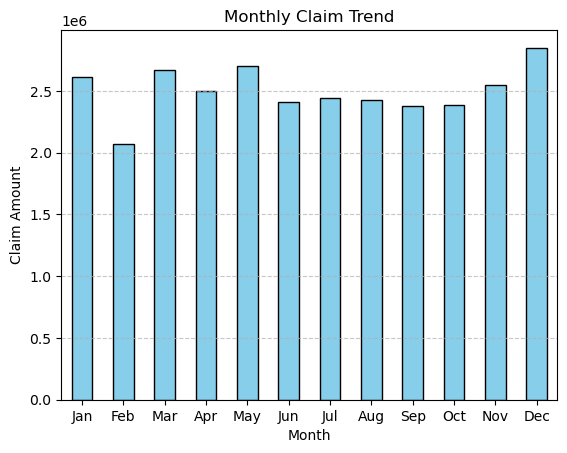

In [ ]:
import matplotlib.pyplot as plt

claims_data["Claim_Date"] = pd.to_datetime(claims_data["Claim_Date"])
claims_data["Month"] = claims_data["Claim_Date"].dt.month

monthly_claims = claims_data.groupby("Month")["Claim_Amount"].sum()

monthly_claims.plot(kind="bar", edgecolor="black", color="skyblue")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Claim Amount")
plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
# x-axis numbers seedhe karne ke liye
plt.xticks(rotation=0)

plt.show()